# titanic 


In [3]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# seaborn에서 제공하는 타이타닉 데이터셋 로드
titanic = sns.load_dataset('titanic')

# 데이터 전처리: 필요한 특성 선택 및 결측치 처리
# 'age'의 결측치를 중앙값으로 채우고, 'embarked'의 결측치를 가장 많은 값으로 채움
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

# 범주형 데이터를 수치형 데이터로 변환
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

# 특성 및 타겟 변수 선택
X = titanic[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y = titanic['survived']

# 데이터를 훈련 세트와 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(X_train)
display(y_train)

,pclass,sex,age,sibsp,parch,fare,embarked
331,1,1,45.5,0,0,28.5000,2
733,2,1,23.0,0,0,13.0000,2
382,3,1,32.0,0,0,7.9250,2
704,3,1,26.0,1,0,7.8542,2
813,3,0,6.0,4,2,31.2750,2
...,...,...,...,...,...,...,...
106,3,0,21.0,0,0,7.6500,2
270,1,1,28.0,0,0,31.0000,2
860,3,1,41.0,2,0,14.1083,2
435,1,0,14.0,1,2,120.0000,2


331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: survived, Length: 712, dtype: int64

In [5]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
# K-Fold 교차 검증 설정
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# C 값의 후보 리스트
c_list = [10e-7, 10e-6, 10e-5, 10e-4, 10e-3, 10e-2, 10e-1, 1, 10, 10^2]
scores_list = []

# 각 C에 대한 교차 검증 수행
for c_val in c_list:
    # 로지스틱 회귀 모델 객체 정의, C 값 설정
    logreg_model = LogisticRegression(C=c_val, solver='liblinear', random_state=42)
    # 교차검증, 분류 문제이므로 정확도를 사용
    scores = cross_val_score(logreg_model, X_train, y_train, scoring='accuracy', cv=kf)
    # 평균 점수 저장
    scores_list.append(np.mean(scores))
scores_list

[np.float64(0.671387767162415),
 np.float64(0.6770117206736925),
 np.float64(0.6756032699694672),
 np.float64(0.6924258839751797),
 np.float64(0.7064709937949375),
 np.float64(0.7963853048360091),
 np.float64(0.7935684034275583),
 np.float64(0.7935684034275583),
 np.float64(0.796385304836009),
 np.float64(0.7977937555402344)]

Best Score: 0.7977937555402344
Optimal C: 8


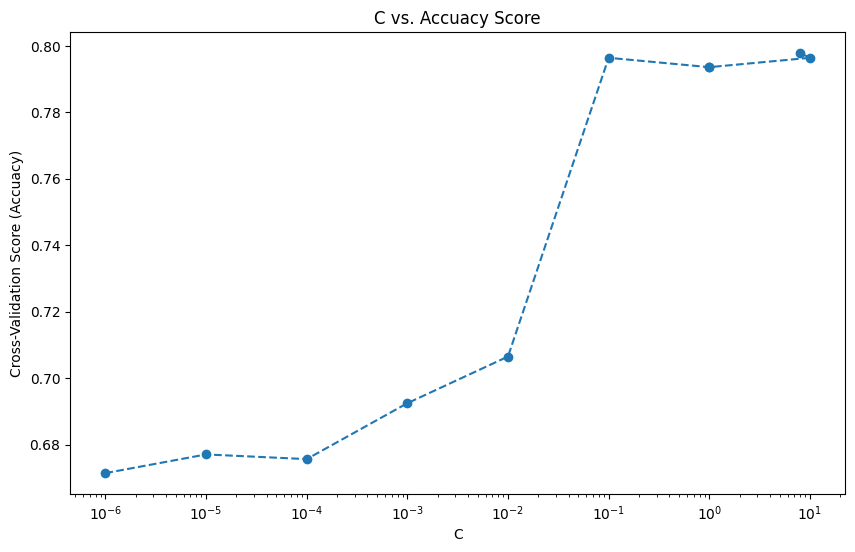

In [8]:
import matplotlib.pyplot as plt
# 최적 alpha 값 및 성능 확인
best_score = max(scores_list) # scores_list에서 최고득점
print(f"Best Score: {best_score}")

optimal_c = c_list[np.argmax(scores_list)] # 최고득점에서의 C의 값
print(f"Optimal C: {optimal_c}")

# 결과 시각화
plt.figure(figsize=(10,6))
plt.plot(c_list, scores_list, marker='o', linestyle='--')
plt.xlabel('C')
plt.ylabel('Cross-Validation Score (Accuacy)')
plt.title('C vs. Accuacy Score')
plt.xscale('log')
plt.show()